# Learning Analytics e Sucesso do Aluno

**Engajamento, Predição e Mineração de Textos em Sistemas EaD com Python**

Este notebook acompanha o livro técnico e utiliza o dataset completo de **20.000 registros**, distribuído em **4 arquivos CSV** (5.000 registros cada):

1. `cap8_dataset_learning_analytics_parte1.csv` (STU0001 a STU5000)
2. `cap8_dataset_learning_analytics_parte2.csv` (STU5001 a STU10000)
3. `cap8_dataset_learning_analytics_parte3.csv` (STU10001 a STU15000)
4. `cap8_dataset_learning_analytics_parte4.csv` (STU15001 a STU20000)

**Objetivo:** percorrer as três frentes de análise:
1. Análise de Engajamento nos Sistemas EaD
2. Modelos Preditivos de Desempenho (classificação e regressão)
3. Mineração de Textos em Fóruns e Atividades

> **Como usar:** execute as células na ordem. Cada célula de código contém comentários explicando o que cada linha faz e por quê.

## 1. Importação das bibliotecas

Aqui carregamos todas as bibliotecas que serão usadas no notebook. Cada uma tem um papel específico no pipeline de ciência de dados.

In [1]:
# ============================================================
# Importação das bibliotecas
# ============================================================

# numpy: fornece operações matemáticas e arrays numéricos.
import numpy as np

# pandas: a biblioteca principal para manipulação de dados tabulares.
import pandas as pd

# matplotlib: biblioteca base para criação de gráficos.
import matplotlib.pyplot as plt

# seaborn: biblioteca de visualização estatística sobre o matplotlib.
import seaborn as sns

# Para a análise de termos mais frequentes usamos apenas matplotlib
# e collections.Counter, evitando dependências adicionais.
from collections import Counter


In [2]:
# ============================================================
# Módulos do scikit-learn (sklearn)
# ============================================================

# train_test_split: divide os dados em conjuntos de treino e teste.
from sklearn.model_selection import train_test_split

# StandardScaler: padroniza as variáveis (média 0 e desvio padrão 1).
# LabelEncoder: converte texto (categorias) em números inteiros.
from sklearn.preprocessing import StandardScaler, LabelEncoder

# LogisticRegression: modelo de classificação linear.
# LinearRegression: modelo de regressão linear.
from sklearn.linear_model import LogisticRegression, LinearRegression

# RandomForestClassifier: modelo de classificação baseado em árvores.
# RandomForestRegressor: modelo de regressão baseado em árvores.
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# TfidfVectorizer: transforma textos em números usando TF-IDF (capítulo 4).
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
# Métricas de avaliação:
# accuracy_score: proporção de acertos na classificação.
# classification_report: relatório com precisão, recall e F1 por classe.
# confusion_matrix: matriz de confusão (acertos e erros por classe).
# roc_auc_score: área sob a curva ROC, mede a capacidade de separar classes.
# mean_absolute_error, mean_squared_error, r2_score: métricas de regressão.

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
# Suprime avisos (warnings) para manter a saída limpa e legível.
import warnings
warnings.filterwarnings('ignore')

# Define o estilo visual padrão dos gráficos (fundo branco com grade).
plt.style.use('seaborn-v0_8-whitegrid')

# Define a fonte padrão dos gráficos como Arial, para consistência visual.
plt.rcParams['font.family'] = 'Arial'

## 2. Carga e concatenação das quatro partes

O dataset completo foi dividido em 4 arquivos CSV de 5.000 registros cada. Carregamos cada parte e as unimos em um único DataFrame com `pd.concat`. Todos os arquivos têm o mesmo formato (mesmas 26 colunas), então a mesma função de leitura é aplicada aos quatro.

In [5]:
# ============================================================
# Carga das quatro partes do dataset
# ============================================================

# Lista com os nomes dos 4 arquivos CSV, na ordem correta.
# Cada arquivo contém 5.000 registros de estudantes.
arquivos = [
    'cap8_dataset_learning_analytics_parte1.csv',
    'cap8_dataset_learning_analytics_parte2.csv',
    'cap8_dataset_learning_analytics_parte3.csv',
    'cap8_dataset_learning_analytics_parte4.csv'
]

In [6]:
# IMPORTANTE: os arquivos foram salvos com separador TAB (\t).
# Por isso usamos sep='\t' na leitura. Sem isso, o pandas leria
# cada linha inteira como uma única coluna.

partes = [pd.read_csv(arquivo, sep='\t') for arquivo in arquivos]

# pd.concat junta os 4 DataFrames em um único, empilhando as linhas.
# ignore_index=True renumera as linhas de 0 a 19999, evitando
# índices duplicados vindos de cada parte.
df = pd.concat(partes, ignore_index=True)

# df.shape retorna (linhas, colunas). Esperamos (20000, 26).
print(f'Dimensões do dataset completo: {df.shape[0]} linhas e {df.shape[1]} colunas')

# df.head() exibe as 5 primeiras linhas do DataFrame concatenado.
df.head()

Dimensões do dataset completo: 20000 linhas e 26 colunas


,student_id,course,age,gender,total_accesses,total_time_minutes,avg_time_per_access,days_active,modules_accessed,lessons_completed,...,forum_reads,threads_started,replies_received,avg_post_length,sentiment_score,help_seeking_posts,weekend_access_ratio,regularity_index,final_grade,status
0,STU0001,Programação I,21,Feminino,83,4527.98,53.68,36,4,19,...,15,3,15,252.09,-0.42,3,0.52,1.58,4.59,Evadido
1,STU0002,Estatística,17,Feminino,126,6643.65,54.19,53,4,12,...,237,9,12,401.92,0.78,6,0.28,1.43,7.28,Aprovado
2,STU0003,Redes de Computadores,22,Masculino,163,3524.50,18.13,49,5,0,...,157,5,9,498.42,0.13,4,0.00,1.00,6.55,Aprovado
3,STU0004,Banco de Dados,29,Feminino,90,2787.22,35.16,61,6,1,...,193,3,8,456.47,0.41,2,0.21,1.30,8.61,Aprovado
4,STU0005,Matemática Discreta,27,Feminino,88,4464.23,55.06,62,5,26,...,98,6,14,699.62,0.43,5,0.24,1.43,3.73,Reprovado


In [7]:
# ============================================================
# Verificação da integridade da concatenação
# ============================================================

# Verificamos se a concatenação não criou duplicatas.
# Como cada linha é um estudante único (STU0001 a STU20000),
# qualquer duplicata indicaria sobreposição entre as partes.

print(f'Linhas duplicadas: {df.duplicated().sum()}')

# Confirmamos que os IDs cobrem todo o intervalo esperado.
# min() e max() retornam o menor e o maior student_id.
print(f'Primeiro ID: {df["student_id"].min()} | Último ID: {df["student_id"].max()}')

Linhas duplicadas: 0
Primeiro ID: STU0001 | Último ID: STU9999


In [8]:
# Contamos quantos registros vieram de cada parte, usando o prefixo
# do student_id para identificar a origem.
# Exemplo: STU0001-STU5000 = parte 1, STU5001-STU10000 = parte 2, etc.

def identificar_parte(sid):
    num = int(sid[3:])
    if num <= 5000:
        return 'Parte 1'
    elif num <= 10000:
        return 'Parte 2'
    elif num <= 15000:
        return 'Parte 3'
    else:
        return 'Parte 4'

df['parte_origem'] = df['student_id'].apply(identificar_parte)
print('\nRegistros por parte:')
print(df['parte_origem'].value_counts().sort_index())



Registros por parte:
parte_origem
Parte 1    5000
Parte 2    5000
Parte 3    5000
Parte 4    5000
Name: count, dtype: int64


## Análise de Engajamento nos Sistemas EaD

O engajamento é o envolvimento comportamental, cognitivo e emocional do estudante, observável pelo rastro digital de interações no AVA. Antes de modelar, precisamos **conhecer os dados**: tipos, distribuições, valores ausentes e outliers.

In [9]:
# ============================================================
# Conhecendo a estrutura e as estatísticas dos dados
# ============================================================

# df.info() mostra o tipo de cada coluna e quantos valores não nulos existem.
# Colunas com contagem menor que 20000 indicam a presença de dados ausentes.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  object 
 1   course                 20000 non-null  object 
 2   age                    20000 non-null  int64  
 3   gender                 20000 non-null  object 
 4   total_accesses         20000 non-null  int64  
 5   total_time_minutes     20000 non-null  float64
 6   avg_time_per_access    20000 non-null  float64
 7   days_active            20000 non-null  int64  
 8   modules_accessed       20000 non-null  int64  
 9   lessons_completed      20000 non-null  int64  
 10  videos_watched         20000 non-null  int64  
 11  video_completion_rate  20000 non-null  float64
 12  quizzes_taken          20000 non-null  int64  
 13  avg_quiz_score         17008 non-null  float64
 14  assignments_submitted  20000 non-null  int64  
 15  fo

In [10]:
# ============================================================
# Dicionário de dados
# ============================================================
# Cria um DataFrame com a descrição de cada coluna, para consulta rápida no estudo.

dicionario = pd.DataFrame({
    'Coluna': ['student_id', 'course', 'age', 'gender', 'total_accesses', 'total_time_minutes', 
               'avg_time_per_access', 'days_active', 'modules_accessed', 'lessons_completed', 
               'videos_watched', 'video_completion_rate', 'quizzes_taken', 'avg_quiz_score', 
               'assignments_submitted', 'forum_posts', 'forum_reads', 'threads_started', 
               'replies_received', 'avg_post_length', 'sentiment_score', 'help_seeking_posts', 
               'weekend_access_ratio', 'regularity_index', 'final_grade', 'status', 
               'parte_origem'], 
    'Tipo': ['object', 'object', 'int64', 'object', 'int64', 'float64',
            'float64', 'int64', 'int64', 'int64', 'int64', 'float64',
            'int64', 'float64', 'int64', 'int64', 'int64', 'int64',
            'int64', 'float64', 'float64', 'int64', 'float64', 'float64',
            'float64', 'object', 'object'],
    'Descricao': 
        ['Identificador único do estudante no AVA', 'Disciplina em que o estudante está matriculado', 
        'Idade do estudante', 'Gênero informado pelo estudante', 'Número total de acessos (logins) ao AVA no período letivo',
        'Tempo total acumulado de permanência no AVA em minutos', 'Tempo médio despendido em cada acesso ao sistema em minutos', 
        'Quantidade de dias distintos com pelo menos um acesso registrado', 'Quantidade de módulos do curso abertos pelo estudante', 
        'Aulas instrucionais marcadas como concluídas', 'Total de conteúdos em vídeo assistidos no ambiente',
        'Percentual médio de reprodução dos vídeos até o encerramento', 'Quantidade de testes rápidos de avaliação realizados', 
        'Nota média obtida nos quizzes realizados', 'Trabalhos práticos e tarefas formais entregues', 
        'Mensagens textuais autorais publicadas nos fóruns', 'Total de visualizações e leituras de mensagens no fórum', 
        'Novos tópicos de discussão inaugurados pelo estudante', 'Respostas de colegas e docentes recebidas nas postagens do aluno', 
        'Média de caracteres por postagem autoral redigida', 'Polaridade média de sentimento das mensagens publicadas',  
        'Postagens caracterizadas semanticamente como solicitação de ajuda', 'Proporção de acessos ao ambiente executados em finais de semana', 
        'Coeficiente de variação dos acessos semanais ao longo do semestre', 'Nota final consolidada obtida no encerramento da disciplina', 
        'Desfecho acadêmico final consolidado na disciplina',''], 
    'Dominio/Faixa': 
        ['Formato STU0001 a STU20000', 'Matemática Discreta, Programação I, Banco de Dados, Redes de Computadores, Estatística',
         '17 a 45 anos', 'Feminino, Masculino, Outro','5 a 250 acessos (com presenças de outliers altos)',
         '60.0 a 9000.0 (outliers até aproximadamente 15000.0)', '3.0 a 60.0 minutos', '1 a 120 dias','1 a 10 módulos', '0 a 40 aulas',
         '0 a 60 vídeos', '0.0 a 100.0 %', '0 a 12 quizzes', '0.0 a 10.0 pontos', '0 a 8 tarefas', '0 a 30 postagens','0 a 400 leituras',
         '0 a 10 tópicos', '0 a 25 respostas','50.0 a 800.0 caracteres','-1.00 (altamente negativo) a +1.00 (altamente positivo)',
         '0 a 10 postagens','0.00 a 1.00','0.10 a 2.50 (valores menores denotam maior regularidade)','0.0 a 10.0 pontos',
         'Aprovado, Reprovado, Evadido','']        
})

dicionario

# Comentário sobre os comandos:
# O dicionário de dados documenta o significado de cada coluna, o tipo e as
# particularidades (valores ausentes, outliers). É a referência conceitual que
# orienta todas as decisões de tratamento e modelagem.

,Coluna,Tipo,Descricao,Dominio/Faixa
0,student_id,object,Identificador único do estudante no AVA,Formato STU0001 a STU20000
1,course,object,Disciplina em que o estudante está matriculado,"Matemática Discreta, Programação I, Banco de D..."
2,age,int64,Idade do estudante,17 a 45 anos
3,gender,object,Gênero informado pelo estudante,"Feminino, Masculino, Outro"
4,total_accesses,int64,Número total de acessos (logins) ao AVA no per...,5 a 250 acessos (com presenças de outliers altos)
5,total_time_minutes,float64,Tempo total acumulado de permanência no AVA em...,60.0 a 9000.0 (outliers até aproximadamente 15...
6,avg_time_per_access,float64,Tempo médio despendido em cada acesso ao siste...,3.0 a 60.0 minutos
7,days_active,int64,Quantidade de dias distintos com pelo menos um...,1 a 120 dias
8,modules_accessed,int64,Quantidade de módulos do curso abertos pelo es...,1 a 10 módulos
9,lessons_completed,int64,Aulas instrucionais marcadas como concluídas,0 a 40 aulas


In [11]:
# df.describe() calcula estatísticas descritivas das colunas numéricas:
# média, desvio padrão, mínimo, quartis (25%, 50%, 75%) e máximo.
# O .T transpoe o resultado (linhas viram colunas) para facilitar a leitura.

print('\nEstatísticas descritivas:')
df.describe().T



Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
age,20000.0,25.021250,5.587536,17.00,21.0000,24.000,28.000,45.0
total_accesses,20000.0,95.567000,70.126215,5.00,28.0000,93.000,150.000,250.0
total_time_minutes,20000.0,2721.370412,2749.013935,60.00,456.4075,1718.405,4489.580,15000.0
avg_time_per_access,20000.0,26.483902,18.403907,3.00,10.2300,23.890,40.080,60.0
days_active,20000.0,41.254500,31.937975,1.00,10.0000,40.000,64.000,120.0
modules_accessed,20000.0,4.048550,2.599814,1.00,1.0000,4.000,6.000,10.0
lessons_completed,20000.0,15.795250,12.138023,0.00,5.0000,15.000,25.000,40.0
videos_watched,20000.0,23.467450,17.991315,0.00,7.0000,22.000,37.000,60.0
video_completion_rate,20000.0,47.295934,25.667403,0.00,28.6200,46.970,65.830,100.0
quizzes_taken,20000.0,4.661550,3.760054,0.00,1.0000,4.000,8.000,12.0


In [12]:
# ============================================================
# Verificação de valores ausentes e duplicatas
# ============================================================

# df.isna() retorna True onde o valor é ausente (NaN).
# .sum() soma os True por coluna, dando a quantidade de ausentes.
# Filtramos apenas as colunas com pelo menos um ausente (sum > 0).
print('Valores ausentes por coluna:')
print(df.isna().sum()[df.isna().sum() > 0])

# df.duplicated() retorna True para linhas duplicadas.
# .sum() conta quantas linhas duplicadas existem.
print(f'\nLinhas duplicadas: {df.duplicated().sum()}')


Valores ausentes por coluna:
avg_quiz_score     2992
avg_post_length    6133
sentiment_score    6133
dtype: int64

Linhas duplicadas: 0


In [13]:
# ============================================================
# Tratamento de valores ausentes (imputação pela mediana)
# ============================================================

# Lista das colunas que apresentam dados ausentes.
# avg_quiz_score: ausente quando o aluno não fez quiz.
# avg_post_length e sentiment_score: ausentes quando o aluno não postou no fórum.
cols_missing = ['avg_quiz_score', 'avg_post_length', 'sentiment_score']

# Para cada coluna com ausentes, preenchemos com a MEDIANA.
# Por que a mediana e não a média? A mediana não é influenciada por outliers,
# sendo a escolha mais segura quando há valores extremos no conjunto.
for col in cols_missing:
    df[col] = df[col].fillna(df[col].median())

# Conferimos se ainda restam valores ausentes nas colunas tratadas.
print('Nulos após imputação:')
print(df[cols_missing].isna().sum())

Nulos após imputação:
avg_quiz_score     0
avg_post_length    0
sentiment_score    0
dtype: int64


In [14]:
# ============================================================
# Tratamento de outliers (winsorização pela regra do IQR)
# ============================================================

# Colunas que podem conter outliers extremos (valores muito acima do normal).
cols_outliers = ['total_accesses', 'total_time_minutes', 'avg_time_per_access']

# Para cada coluna, aplicamos a regra do IQR (Intervalo Interquartil):
# - Q1 = primeiro quartil (25% dos dados estão abaixo)
# - Q3 = terceiro quartil (75% dos dados estão abaixo)
# - IQR = Q3 - Q1 (amplitude do meio dos dados)
# Limites: valores abaixo de Q1 - 1.5*IQR ou acima de Q3 + 1.5*IQR são outliers.
for col in cols_outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    # np.clip limita os valores aos limites calculados.
    # Isso é a WINSORIZAÇÃO: não descartamos a linha, apenas neutralizamos
    # o efeito do valor extremo, preservando o registro do estudante.
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print('Outliers tratados com winsorização.')

Outliers tratados com winsorização.


In [15]:
# ============================================================
# Engenharia de atributos (índice de engajamento)
# ============================================================

# Criamos uma NOVA variável chamada engagement_index (0 a 1).
# Ela sintetiza vários indicadores de engajamento em um único score.
# Cada componente é normalizado pela sua escala máxima (dividido pelo max),
# ficando entre 0 e 1, e depois ponderado pela sua importância presumida.

# 20% de peso: volume de acessos (normalizado pelo máximo)
# 20% de peso: dias ativos (normalizado pelo máximo)
# 20% de peso: aulas concluídas (normalizado pelo máximo)
# 15% de peso: quizzes realizados (normalizado pelo máximo)
# 15% de peso: trabalhos entregues (normalizado pelo máximo)
# 10% de peso: postagens no fórum (normalizado pelo máximo)
df['engagement_index'] = (
    0.20 * (df['total_accesses'] / df['total_accesses'].max()) +
    0.20 * (df['days_active'] / df['days_active'].max()) +
    0.20 * (df['lessons_completed'] / df['lessons_completed'].max()) +
    0.15 * (df['quizzes_taken'] / df['quizzes_taken'].max()) +
    0.15 * (df['assignments_submitted'] / df['assignments_submitted'].max()) +
    0.10 * (df['forum_posts'] / df['forum_posts'].max())
)

# Exibimos as estatísticas do novo índice para entender sua distribuição.
print(df['engagement_index'].describe())

count    20000.000000
mean         0.368962
std          0.255964
min          0.005667
25%          0.138400
50%          0.354850
75%          0.566438
max          1.000000
Name: engagement_index, dtype: float64


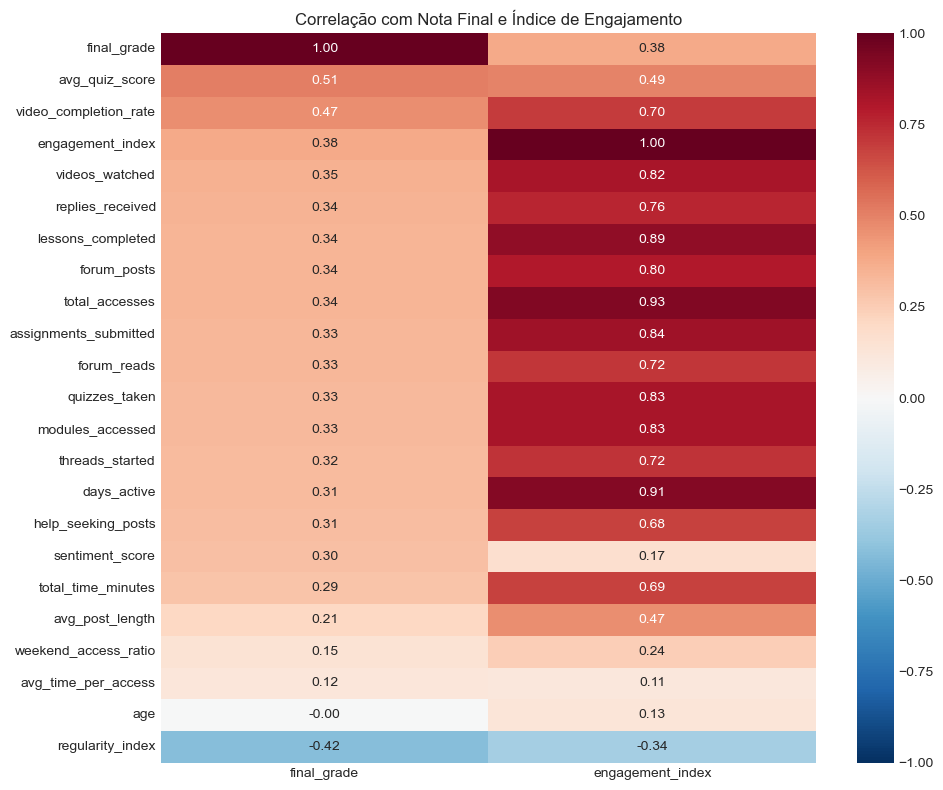

In [16]:
# ============================================================
# Matriz de correlação com as variáveis alvo
# ============================================================

# select_dtypes(include=[np.number]) seleciona apenas colunas numéricas,
# pois a correlação só faz sentido entre números.
# .corr() calcula a correlação de Pearson entre todas as colunas numéricas.
# O resultado é uma matriz onde cada célula varia de -1 (correlação inversa)
# a +1 (correlação direta).
corr = df.select_dtypes(include=[np.number]).corr()

# Criamos uma figura de 10x8 polegadas.
plt.figure(figsize=(10, 8))

# sns.heatmap desenha a matriz de correlação como um mapa de calor.
# Selecionamos apenas as colunas final_grade e engagement_index,
# ordenadas pela correlação com a nota final (sort_values).
# annot=True mostra os valores numéricos em cada célula.
# cmap='RdBu_r' usa vermelho para negativo e azul para positivo.
# vmin=-1 e vmax=1 fixam a escala da cor.
sns.heatmap(corr[['final_grade', 'engagement_index']].sort_values('final_grade', ascending=False),
            annot=True, cmap='RdBu_r', fmt='.2f', vmin=-1, vmax=1)

plt.title('Correlação com Nota Final e Índice de Engajamento')
plt.tight_layout()
plt.show()

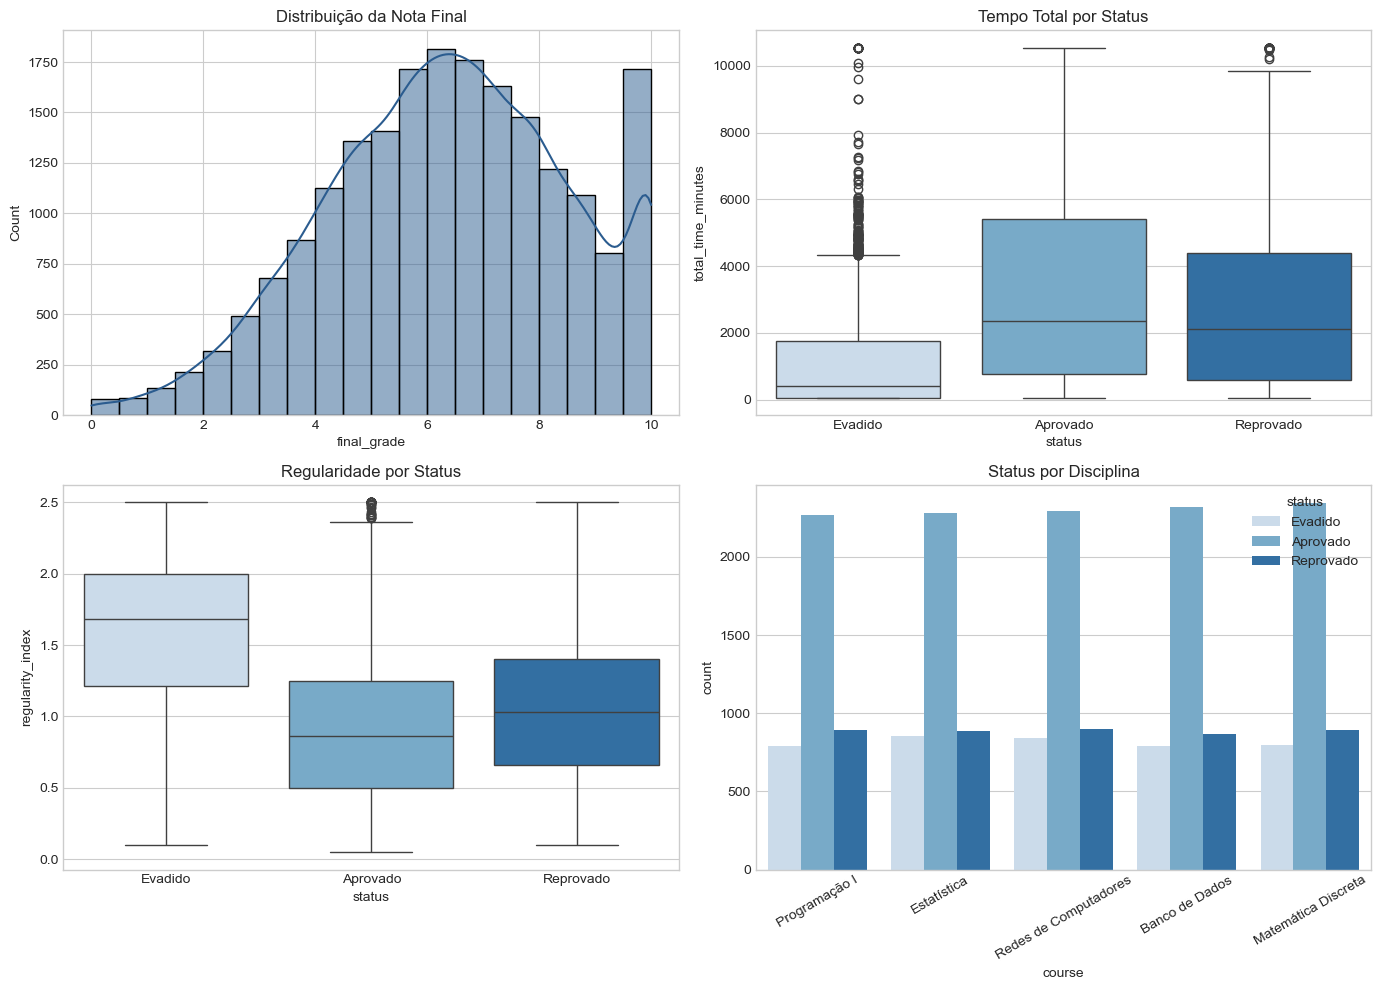

In [17]:
# ============================================================
# Visualizações do engajamento por status
# ============================================================

# plt.subplots(2, 2) cria uma grade de 2x2 de gráficos.
# fig é a figura inteira; axes é uma matriz com os 4 eixos (gráficos).
# figsize=(14, 10) define o tamanho total da figura.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# GRÁFICO 1 (linha 0, coluna 0): histograma da nota final.
# bins=20 divide o intervalo em 20 barras; kde=True adiciona a curva de densidade.
sns.histplot(df['final_grade'], bins=20, kde=True, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title('Distribuição da Nota Final')

# GRÁFICO 2 (linha 0, coluna 1): boxplot do tempo total por status.
# O boxplot mostra quartis, mediana e outliers de cada grupo.
sns.boxplot(x='status', y='total_time_minutes', data=df, ax=axes[0, 1], palette='Blues')
axes[0, 1].set_title('Tempo Total por Status')

# GRÁFICO 3 (linha 1, coluna 0): boxplot do índice de regularidade por status.
# Lembre-se: quanto MENOR o regularity_index, mais regular é o estudante.
sns.boxplot(x='status', y='regularity_index', data=df, ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title('Regularidade por Status')

# GRÁFICO 4 (linha 1, coluna 1): contagem de status por disciplina.
# countplot conta quantos alunos de cada status existem em cada curso.
# hue='status' separa as barras por desfecho acadêmico.
sns.countplot(x='course', hue='status', data=df, ax=axes[1, 1], palette='Blues')
axes[1, 1].set_title('Status por Disciplina')
axes[1, 1].tick_params(axis='x', rotation=30)

# Ajusta o espaçamento entre os gráficos para não sobrepor os títulos.
plt.tight_layout()
plt.show()


**Interpretação do Capítulo 2:**

Aprovados tendem a ter mais acessos, mais tempo no ambiente e menor `regularity_index` (acesso regular e disciplinado). Evadidos concentram baixo engajamento e afastamento precoce das rotinas do AVA. A correlação confirma que o engajamento é o principal motor do desempenho.

## Modelos Preditivos de Desempenho

Aprendizado supervisionado: treinamos modelos com dados rotulados para prever resultados. Aqui fazemos **classificação** (prever o `status`: Aprovado/Reprovado/Evadido) e **regressão** (prever a `final_grade`: nota de 0 a 10).

In [18]:
# ============================================================
# Preparação dos dados para modelagem
# ============================================================

# Copiamos o DataFrame para não alterar o original durante a modelagem.
df_model = df.copy()

# LabelEncoder converte a coluna textual 'course' em números inteiros.
# Cada disciplina recebe um código (0, 1, 2, ...).
# Isso é necessário porque algoritmos de ML só trabalham com números.
le_course = LabelEncoder()
df_model['course_encoded'] = le_course.fit_transform(df_model['course'])

# Lista das variáveis PREDITORAS (features) usadas pelos modelos.
# Excluímos student_id (identificação), parte_origem (controle) e as
# variáveis alvo. Incluímos o engagement_index criado na Célula 8.
features = ['course_encoded', 'age', 'total_accesses', 'total_time_minutes',
            'avg_time_per_access', 'days_active', 'modules_accessed',
            'lessons_completed', 'videos_watched', 'video_completion_rate',
            'quizzes_taken', 'avg_quiz_score', 'assignments_submitted',
            'forum_posts', 'forum_reads', 'threads_started', 'replies_received',
            'avg_post_length', 'sentiment_score', 'help_seeking_posts',
            'weekend_access_ratio', 'regularity_index', 'engagement_index']



In [19]:
# X contém as variáveis preditoras (entrada dos modelos).
X = df_model[features]

# y_class é a variável alvo da CLASSIFICAÇÃO (status).
y_class = df_model['status']

# y_reg é a variável alvo da REGRESSÃO (nota final).
y_reg = df_model['final_grade']

# train_test_split divide os dados em treino (75%) e teste (25%).
# test_size=0.25 define a proporção do teste.
# random_state=42 garante que a divisão seja reprodutível (mesmo resultado sempre).
# stratify=y_class mantém a mesma proporção de classes no treino e no teste,
# evitando que uma classe fique sub-representada em alguma das partições.
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.25, random_state=42, stratify=y_class
)

# StandardScaler padroniza as variáveis: média 0 e desvio padrão 1.
# Isso é importante para modelos lineares, que são sensíveis à escala.
# Ajustamos (fit) apenas no TREINO e aplicamos (transform) no TESTE,
# para não vazar informação do teste para o treino.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Divisão concluída:', X_train.shape, X_test.shape)

Divisão concluída: (15000, 23) (5000, 23)


In [20]:
# ============================================================
# Classificação do status (Regressão Logística e Random Forest)
# ============================================================

# --- MODELO 1: Regressão Logística ---
# multi_class='multinomial' habilita a classificação com 3 classes.
# max_iter=1000 aumenta o limite de iterações para garantir convergência.
# Usamos os dados PADRONIZADOS (scaled), pois a regressão logística é linear.
clf_lr = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
clf_lr.fit(X_train_scaled, y_class_train)

# predict retorna a classe prevista para cada exemplo do teste.
pred_lr = clf_lr.predict(X_test_scaled)

# predict_proba retorna a PROBABILIDADE de cada classe (soma 1 por linha).
# Necessário para calcular o ROC-AUC.
prob_lr = clf_lr.predict_proba(X_test_scaled)


In [21]:
# --- MODELO 2: Random Forest ---
# n_estimators=150: quantidade de árvores de decisão no conjunto.
# max_depth=10: profundidade máxima de cada árvore (evita overfitting).
# O Random Forest não exige padronização, então usamos X_train (sem scale).
clf_rf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
clf_rf.fit(X_train, y_class_train)
pred_rf = clf_rf.predict(X_test)
prob_rf = clf_rf.predict_proba(X_test)


In [22]:
# --- Avaliação do Modelo 1 ---
print('=== Regressão Logística ===')
# accuracy_score: proporção de previsões corretas sobre o total.
print(f'Acurácia: {accuracy_score(y_class_test, pred_lr):.3f}')
# roc_auc_score com multi_class='ovr' (one-vs-rest): mede a capacidade
# do modelo de distinguir cada classe das demais. Quanto mais perto de 1, melhor.
print(f'ROC-AUC (ovr): {roc_auc_score(y_class_test, prob_lr, multi_class="ovr"):.3f}')
# classification_report mostra precisão, recall e F1 para cada classe.
# Preste atenção no recall da classe Evadido: é o custo de NÃO identificar
# quem vai evadir, o erro mais caro neste problema.
print(classification_report(y_class_test, pred_lr))


=== Regressão Logística ===
Acurácia: 0.704
ROC-AUC (ovr): 0.834
              precision    recall  f1-score   support

    Aprovado       0.72      0.89      0.80      2876
     Evadido       0.69      0.73      0.71      1016
   Reprovado       0.57      0.20      0.30      1108

    accuracy                           0.70      5000
   macro avg       0.66      0.61      0.60      5000
weighted avg       0.68      0.70      0.67      5000



In [23]:
# --- Avaliação do Modelo 2 ---
print('=== Random Forest ===')
print(f'Acurácia: {accuracy_score(y_class_test, pred_rf):.3f}')
print(f'ROC-AUC (ovr): {roc_auc_score(y_class_test, prob_rf, multi_class="ovr"):.3f}')
print(classification_report(y_class_test, pred_rf))

=== Random Forest ===
Acurácia: 0.744
ROC-AUC (ovr): 0.878
              precision    recall  f1-score   support

    Aprovado       0.75      0.88      0.81      2876
     Evadido       0.76      0.81      0.79      1016
   Reprovado       0.65      0.33      0.44      1108

    accuracy                           0.74      5000
   macro avg       0.72      0.67      0.68      5000
weighted avg       0.73      0.74      0.72      5000



In [24]:
# ============================================================
# Regressão da nota final (Linear e Random Forest)
# ============================================================

# --- MODELO 1: Regressão Linear ---
# Modelo clássico que assume relação linear entre preditores e alvo.
# Usa os dados padronizados (scaled).
reg_lin = LinearRegression()
reg_lin.fit(X_train_scaled, y_reg_train)
pred_lin = reg_lin.predict(X_test_scaled)


In [25]:
# --- MODELO 2: Random Forest Regressor ---
# Versão de regressão do Random Forest, capaz de capturar relações não lineares.
reg_rf = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42)
reg_rf.fit(X_train, y_reg_train)
pred_reg_rf = reg_rf.predict(X_test)

# Função auxiliar para avaliar e exibir as métricas de regressão.
# MAE (erro absoluto médio): em média, quanto o modelo erra em pontos.
# RMSE (raiz do erro quadrático médio): penaliza erros grandes.
# R² (coeficiente de determinação): proporção da variância explicada (0 a 1).
def avaliar_regressao(nome, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{nome} -> MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}')

avaliar_regressao('Regressão Linear', y_reg_test, pred_lin)
avaliar_regressao('Random Forest Regressor', y_reg_test, pred_reg_rf)

Regressão Linear -> MAE: 1.344 | RMSE: 1.693 | R2: 0.386
Random Forest Regressor -> MAE: 1.298 | RMSE: 1.645 | R2: 0.420


In [26]:
# ============================================================
# Importância de atributos (Random Forest)
# ============================================================

# feature_importances_ retorna o quanto cada variável contribuiu para as
# decisões das árvores. Valores maiores = mais influência na previsão.
# Criamos uma Series com os nomes das features como índice e ordenamos
# do maior para o menor (ascending=False).
importancias_clf = pd.Series(clf_rf.feature_importances_, index=features).sort_values(ascending=False)
importancias_reg = pd.Series(reg_rf.feature_importances_, index=features).sort_values(ascending=False)


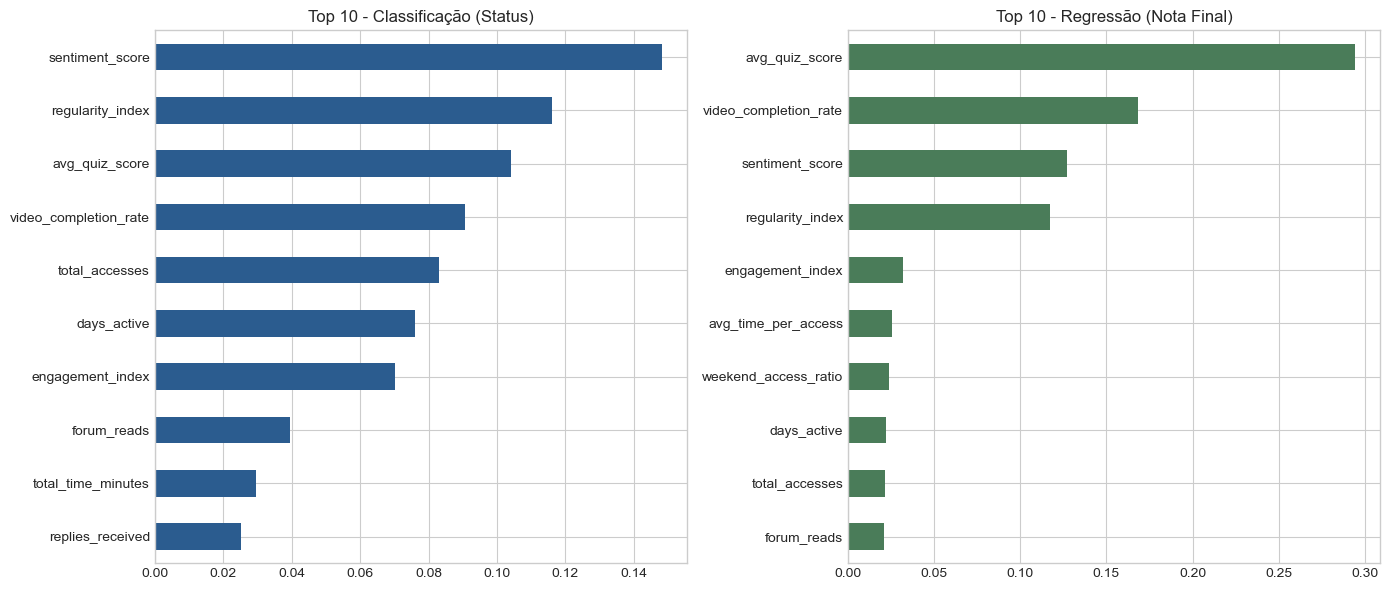

In [27]:
# Criamos uma figura com 2 gráficos lado a lado.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: top 10 importâncias da CLASSIFICAÇÃO (status).
# kind='barh' gera barras horizontais; invert_yaxis coloca o maior no topo.
importancias_clf.head(10).plot(kind='barh', ax=axes[0], color='#2b5c8f')
axes[0].set_title('Top 10 - Classificação (Status)')
axes[0].invert_yaxis()

# Gráfico 2: top 10 importâncias da REGRESSÃO (nota final).
importancias_reg.head(10).plot(kind='barh', ax=axes[1], color='#4a7c59')
axes[1].set_title('Top 10 - Regressão (Nota Final)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Interpretação do Capítulo 3:**

O Random Forest tende a superar a Regressão Logística na classificação, com maior recall da classe Evadido, essencial para intervenção precoce. Na regressão, o Random Forest também erra menos (menor MAE/RMSE) e explica mais a variância (maior R²). O engajamento e as entregas práticas dominam a importância de atributos.

## Mineração de Textos em Fóruns e Atividades

Extraímos sinais do comportamento textual dos estudantes: comprimento das postagens, sentimento e pedidos de ajuda. O texto dos fóruns é uma fonte rica de sinais precoces de risco.

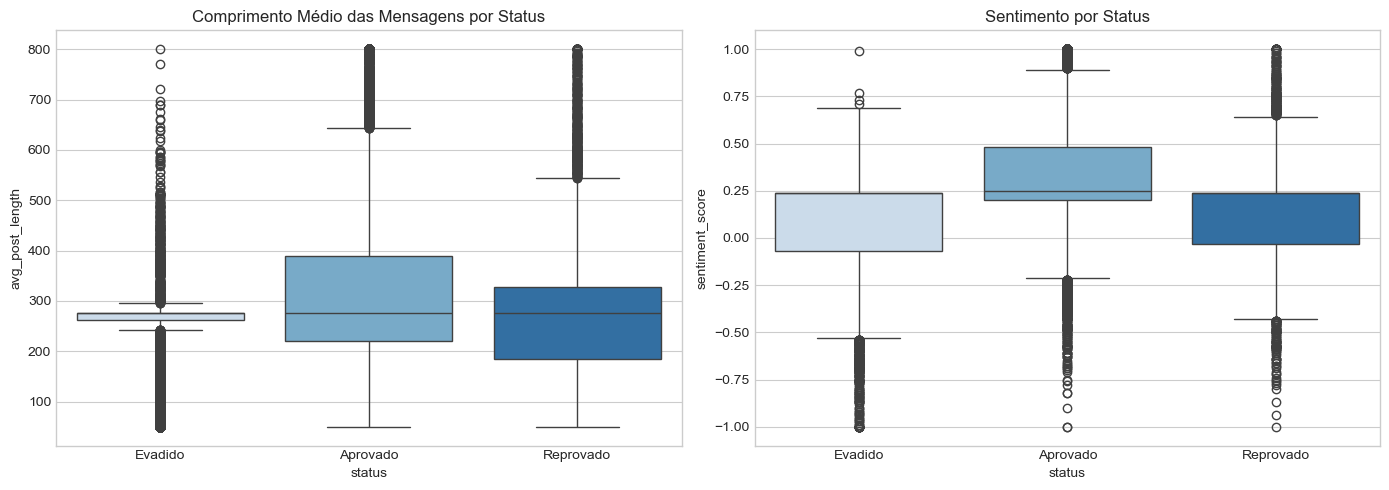

In [28]:
# ============================================================
# Análise descritiva do comportamento textual
# ============================================================

# Criamos uma figura com 2 gráficos lado a lado.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: boxplot do comprimento médio das postagens por status.
# Mostra se aprovados escrevem mensagens mais longas que evadidos.
sns.boxplot(x='status', y='avg_post_length', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Comprimento Médio das Mensagens por Status')

# Gráfico 2: boxplot do sentimento por status.
# Mostra a polaridade média do discurso de cada grupo (-1 a +1).
sns.boxplot(x='status', y='sentiment_score', data=df, ax=axes[1], palette='Blues')
axes[1].set_title('Sentimento por Status')

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# Construção de um corpus sintético de postagens
# ============================================================

# O dataset não traz o texto bruto das postagens, apenas resumos numéricos
# (comprimento, sentimento, pedidos de ajuda). Para demonstrar as técnicas
# de mineração de texto, criamos um corpus SINTÉTICO: uma função que gera
# uma postagem representativa para cada estudante, com base no seu perfil.

def gerar_postagem(row):
    # Estudante evadido: postagem curta, negativa, com falhas operacionais.
    if row['status'] == 'Evadido':
        return 'Nao consigo acessar as aulas. O sistema da erro no compilador e estou perdido na materia.'
    # Estudante reprovado: varia conforme o volume de pedidos de ajuda.
    elif row['status'] == 'Reprovado':
        if row['help_seeking_posts'] > 2:
            return 'Tenho muitas duvidas nos ponteiros e na lista de algoritmos. Nao compreendi os exercicios.'
        return 'Achei a prova dificil e nao entreguei os prazos das atividades semanais.'
    # Estudante aprovado: postagem positiva, colaborativa, de validação.
    else:
        if row['sentiment_score'] > 0.3:
            return 'Excelente material de apoio. Consegui resolver o projeto final e compartilhar os codigos.'
        return 'Consegui finalizar a entrega dos codigos. A discussao sobre estrutura de dados ajudou muito.'

# df.apply aplica a função a cada linha (axis=1) e guarda o resultado
# em uma nova coluna chamada corpus_textual.
df['corpus_textual'] = df.apply(gerar_postagem, axis=1)

# Exibimos uma amostra para conferir o resultado.
print(df[['status', 'corpus_textual']].head(5))

      status                                     corpus_textual
0    Evadido  Nao consigo acessar as aulas. O sistema da err...
1   Aprovado  Excelente material de apoio. Consegui resolver...
2   Aprovado  Consegui finalizar a entrega dos codigos. A di...
3   Aprovado  Excelente material de apoio. Consegui resolver...
4  Reprovado  Tenho muitas duvidas nos ponteiros e na lista ...


In [30]:
# ============================================================
# TF-IDF (transformando texto em números)
# ============================================================

# Lista de stopwords (palavras de ligação) em português.
# Stopwords são removidas porque não carregam informação útil para a análise.
stopwords_pt = ['a', 'o', 'e', 'de', 'do', 'da', 'em', 'um', 'uma', 'os', 'as',
                'dos', 'das', 'na', 'no', 'nas', 'nos', 'com', 'por', 'para',
                'nao', 'estou', 'muito']

# TfidfVectorizer converte o corpus em uma matriz numérica.
# TF-IDF = Term Frequency - Inverse Document Frequency:
# - TF: frequência do termo dentro do documento (quanto mais aparece, mais pesa).
# - IDF: pondera pela raridade no corpus (termos raros ganham mais peso).
# max_features=50 limita o vocabulário aos 50 termos mais relevantes.
# stop_words recebe nossa lista de stopwords em português.
tfidf = TfidfVectorizer(max_features=50, stop_words=stopwords_pt)
matriz_tfidf = tfidf.fit_transform(df['corpus_textual'])

# get_feature_names_out() retorna os termos do vocabulário.
# Exibimos os 15 primeiros para inspecionar o que foi extraído.
print('Vocabulário extraído (top 15):')
print(tfidf.get_feature_names_out()[:15])


Vocabulário extraído (top 15):
['acessar' 'achei' 'ajudou' 'algoritmos' 'apoio' 'atividades' 'aulas'
 'codigos' 'compartilhar' 'compilador' 'compreendi' 'consegui' 'consigo'
 'dados' 'dificil']


In [31]:
# ============================================================
# Termos mais frequentes por grupo
# ============================================================

# Função que conta a frequência das palavras de um grupo de textos.
# Recebe uma lista de postagens e retorna as N palavras mais comuns.
def termos_mais_frequentes(textos, n=10):
    # split() separa cada postagem em palavras individuais.
    # Counter conta quantas vezes cada palavra aparece no conjunto.
    contador = Counter()
    for texto in textos:
        contador.update(texto.split())
    # most_common(n) retorna as n palavras mais frequentes.
    return contador.most_common(n)

# Aplicamos a função para cada grupo de status.
# df[df['status'] == 'Aprovado']['corpus_textual'] seleciona apenas
# as postagens dos estudantes aprovados.
termos_aprovados = termos_mais_frequentes(df[df['status'] == 'Aprovado']['corpus_textual'])
termos_evadidos = termos_mais_frequentes(df[df['status'] == 'Evadido']['corpus_textual'])



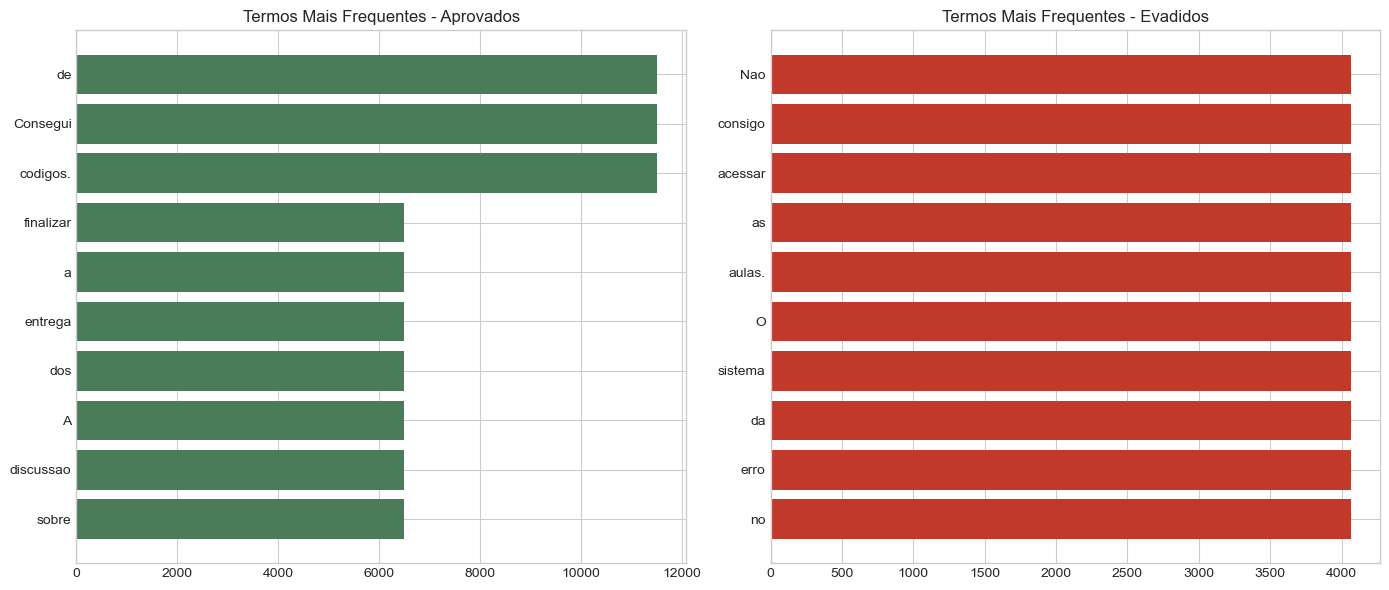

In [32]:
# Criamos uma figura com 2 gráficos lado a lado.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: termos mais frequentes entre aprovados.
# zip(*termos) separa a lista de tuplas (palavra, contagem) em duas listas:
# palavras e contagens.
palavras_ap, contagens_ap = zip(*termos_aprovados)
axes[0].barh(palavras_ap, contagens_ap, color='#4a7c59')
axes[0].set_title('Termos Mais Frequentes - Aprovados')
axes[0].invert_yaxis()  # coloca a palavra mais frequente no topo

# Gráfico 2: termos mais frequentes entre evadidos.
palavras_ev, contagens_ev = zip(*termos_evadidos)
axes[1].barh(palavras_ev, contagens_ev, color='#c0392b')
axes[1].set_title('Termos Mais Frequentes - Evadidos')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()



In [33]:
# ============================================================
# Sentimento como sinal de risco
# ============================================================

# .corr() entre duas colunas calcula a correlação de Pearson entre elas.
# Um valor positivo indica que, quanto mais positivo o sentimento,
# maior tende a ser a nota final.
corr_sent = df['sentiment_score'].corr(df['final_grade'])
print(f'Correlação Sentimento x Nota Final: {corr_sent:.3f}')

# groupby('status') agrupa os dados por desfecho acadêmico.
# .agg(['mean', 'std', 'median']) calcula média, desvio padrão e mediana
# do sentimento para cada grupo.
print('\nSentimento médio por status:')
print(df.groupby('status')['sentiment_score'].agg(['mean', 'std', 'median']))


Correlação Sentimento x Nota Final: 0.299

Sentimento médio por status:
               mean       std  median
status                               
Aprovado   0.312136  0.271327    0.25
Evadido    0.072403  0.294987    0.24
Reprovado  0.141855  0.271694    0.24


**Interpretação do Capítulo 4:**

O sentimento das postagens se correlaciona com o desempenho e diferencia os grupos: aprovados escrevem mensagens mais longas e positivas, evadidos postam pouco e com sentimento negativo. O texto dos fóruns é uma fonte rica de sinais precoces e complementa os dados numéricos de engajamento.

## Considerações Finais

O pipeline completo, do diagnóstico ao modelo preditivo e à mineração de textos, permite identificar precocemente estudantes em risco. Recomenda-se aplicar o mesmo fluxo em dados reais da instituição, validar com novos semestres e envolver educadores na interpretação dos resultados para transformar previsão em ação pedagógica.